# Movie Revenue Prediction Using Machine Learning

# Data Science Mini Project

**Student Name   : ASWINKUMAR R**

**Batch          : DS AN B03**

**Project Title  : Movie Revenue Prediction USing Machine Learning**

**Submission Date:**

## **Project Overview**

The objective of this project is to develop a supervised machine learning regression model that predicts the revenue generated by a movie using its available characteristics.

The project uses the Movies Recommendation.csv dataset, which contains information about thousands of movies, including budget, popularity, runtime, ratings, vote counts, genre, language, production country, director, release date, and revenue.

The project follows a complete Data Science and Machine Learning workflow:

Data Collection → Data Understanding → Data Cleaning → Exploratory Data Analysis → Feature Engineering → Feature Selection → Data Preprocessing → Model Building → Model Evaluation → Model Comparison → Prediction → Deployment

The project converts the original movie dataset into a supervised learning problem by selecting Movie_Revenue as the target variable.

**Objectives**

The major objectives of the project are:

1. Understand the movie dataset.
2. Analyze the distribution and characteristics of movie revenue.
3. Identify relationships between movie attributes and revenue.
4. Handle missing values and duplicate records.
5. Detect and manage skewed numerical variables.
6. Convert categorical variables into machine-readable format.
7. Scale numerical features where required.
8. Perform feature engineering.
9. Build multiple supervised regression models.
10. Compare model performance using appropriate regression metrics.
11. Analyze overfitting and underfitting.
12. Select a suitable model based on evaluation results.
13. Save the trained model.
14. Develop a Flask API for movie revenue prediction.
15. Prepare the model for deployment.

## 1. Import libraries

In [69]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [70]:
# ==============================
# 2. LOAD DATASET
# ==============================

df = pd.read_csv("Movies Recommendation.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (4760, 21)


,Movie_ID,Movie_Title,Movie_Genre,Movie_Language,Movie_Budget,Movie_Popularity,Movie_Release_Date,Movie_Revenue,Movie_Runtime,Movie_Vote,...,Movie_Homepage,Movie_Keywords,Movie_Overview,Movie_Production_House,Movie_Production_Country,Movie_Spoken_Language,Movie_Tagline,Movie_Cast,Movie_Crew,Movie_Director
0,1,Four Rooms,Crime Comedy,en,4000000,22.876230,09-12-1995,4300000,98.0,6.5,...,NaN,hotel new year's eve witch bet hotel room,It's Ted the Bellhop's first night on the job....,"[{""name"": ""Miramax Films"", ""id"": 14}, {""name"":...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",Twelve outrageous guests. Four scandalous requ...,Tim Roth Antonio Banderas Jennifer Beals Madon...,"[{'name': 'Allison Anders', 'gender': 1, 'depa...",Allison Anders
1,2,Star Wars,Adventure Action Science Fiction,en,11000000,126.393695,25-05-1977,775398007,121.0,8.1,...,http://www.starwars.com/films/star-wars-episod...,android galaxy hermit death star lightsaber,Princess Leia is captured and held hostage by ...,"[{""name"": ""Lucasfilm"", ""id"": 1}, {""name"": ""Twe...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","A long time ago in a galaxy far, far away...",Mark Hamill Harrison Ford Carrie Fisher Peter ...,"[{'name': 'George Lucas', 'gender': 2, 'depart...",George Lucas
2,3,Finding Nemo,Animation Family,en,94000000,85.688789,30-05-2003,940335536,100.0,7.6,...,http://movies.disney.com/finding-nemo,father son relationship harbor underwater fish...,"Nemo, an adventurous young clownfish, is unexp...","[{""name"": ""Pixar Animation Studios"", ""id"": 3}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","There are 3.7 trillion fish in the ocean, they...",Albert Brooks Ellen DeGeneres Alexander Gould ...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton
3,4,Forrest Gump,Comedy Drama Romance,en,55000000,138.133331,06-07-1994,677945399,142.0,8.2,...,NaN,vietnam veteran hippie mentally disabled runni...,A man with a low IQ has accomplished great thi...,"[{""name"": ""Paramount Pictures"", ""id"": 4}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","The world will never be the same, once you've ...",Tom Hanks Robin Wright Gary Sinise Mykelti Wil...,"[{'name': 'Alan Silvestri', 'gender': 2, 'depa...",Robert Zemeckis
4,5,American Beauty,Drama,en,15000000,80.878605,15-09-1999,356296601,122.0,7.9,...,http://www.dreamworks.com/ab/,male nudity female nudity adultery midlife cri...,"Lester Burnham, a depressed suburban father in...","[{""name"": ""DreamWorks SKG"", ""id"": 27}, {""name""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",Look closer.,Kevin Spacey Annette Bening Thora Birch Wes Be...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes


## 3. Problem Definition

Movie revenue is influenced by several factors such as production budget, popularity, audience ratings, number of votes, movie genre, release period, language, and production country.

The objective is to build a machine learning model that can learn relationships between these movie characteristics and historical revenue and then estimate the expected revenue for a new movie.

### Problem Type

Supervised Learning – Regression

### Target Variable

Movie_Revenue

### Input Variables

The major input features used are:

Movie_Budget
Movie_Popularity
Movie_Runtime
Movie_Vote
Movie_Vote_Count
Release_Year
Release_Month
Movie_Genre
Movie_Language
Movie_Production_Country

In [71]:
# ==============================
# 3. PROBLEM DEFINITION
# ==============================

print("""
PROJECT: Movie Revenue Prediction

Problem Statement:
Predict the revenue generated by a movie using
its available movie characteristics.

Machine Learning Type:
Supervised Learning

Problem Type:
Regression

Target Variable:
Movie_Revenue
""")


PROJECT: Movie Revenue Prediction

Problem Statement:
Predict the revenue generated by a movie using
its available movie characteristics.

Machine Learning Type:
Supervised Learning

Problem Type:
Regression

Target Variable:
Movie_Revenue



## 4. Dataset Understanding

The dataset used is:

Movies Recommendation.csv

The dataset contains approximately:

4,760 movie records
21 original features

Therefore, the dataset satisfies the project guideline requirement of at least 1,000 records and 10 features.

Important Features
Feature	Description
* Movie_ID :	Unique movie identifier
* Movie_Title :	Name of the movie
* Movie_Genre	: Genre or genre combination
* Movie_Language :	Primary movie language
* Movie_Budget :	Production budget
* Movie_Popularity :	Popularity score
* Movie_Release_Date :	Movie release date
* Movie_Revenue	: Revenue generated by the movie
* Movie_Runtime	: Movie duration
* Movie_Vote	: Average audience rating
* Movie_Vote_Count :	Number of votes
* Movie_Keywords	: Keywords associated with movie
* Movie_Overview	: Movie description
* Movie_Production_House :	Production company
* Movie_Production_Country :	Production country
* Movie_Spoken_Language	: Spoken languages
* Movie_Tagline	: Movie tagline
* Movie_Cast	: Cast information
* Movie_Crew	: Crew information
* Movie_Director :	Director
* Movie_Homepage :	Movie website

In [72]:
# ==============================
# 4. DATASET UNDERSTANDING
# ==============================

print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Shape:
(4760, 21)

Columns:
['Movie_ID', 'Movie_Title', 'Movie_Genre', 'Movie_Language', 'Movie_Budget', 'Movie_Popularity', 'Movie_Release_Date', 'Movie_Revenue', 'Movie_Runtime', 'Movie_Vote', 'Movie_Vote_Count', 'Movie_Homepage', 'Movie_Keywords', 'Movie_Overview', 'Movie_Production_House', 'Movie_Production_Country', 'Movie_Spoken_Language', 'Movie_Tagline', 'Movie_Cast', 'Movie_Crew', 'Movie_Director']

Data Types:
Movie_ID                      int64
Movie_Title                  object
Movie_Genre                  object
Movie_Language               object
Movie_Budget                  int64
Movie_Popularity            float64
Movie_Release_Date           object
Movie_Revenue                 int64
Movie_Runtime               float64
Movie_Vote                  float64
Movie_Vote_Count              int64
Movie_Homepage               object
Movie_Keywords               object
Movie_Overview               object
Movie_Production_House       object
Movie_Production_Country     object


,Movie_ID,Movie_Title,Movie_Genre,Movie_Language,Movie_Budget,Movie_Popularity,Movie_Release_Date,Movie_Revenue,Movie_Runtime,Movie_Vote,...,Movie_Homepage,Movie_Keywords,Movie_Overview,Movie_Production_House,Movie_Production_Country,Movie_Spoken_Language,Movie_Tagline,Movie_Cast,Movie_Crew,Movie_Director
0,1,Four Rooms,Crime Comedy,en,4000000,22.876230,09-12-1995,4300000,98.0,6.5,...,NaN,hotel new year's eve witch bet hotel room,It's Ted the Bellhop's first night on the job....,"[{""name"": ""Miramax Films"", ""id"": 14}, {""name"":...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",Twelve outrageous guests. Four scandalous requ...,Tim Roth Antonio Banderas Jennifer Beals Madon...,"[{'name': 'Allison Anders', 'gender': 1, 'depa...",Allison Anders
1,2,Star Wars,Adventure Action Science Fiction,en,11000000,126.393695,25-05-1977,775398007,121.0,8.1,...,http://www.starwars.com/films/star-wars-episod...,android galaxy hermit death star lightsaber,Princess Leia is captured and held hostage by ...,"[{""name"": ""Lucasfilm"", ""id"": 1}, {""name"": ""Twe...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","A long time ago in a galaxy far, far away...",Mark Hamill Harrison Ford Carrie Fisher Peter ...,"[{'name': 'George Lucas', 'gender': 2, 'depart...",George Lucas
2,3,Finding Nemo,Animation Family,en,94000000,85.688789,30-05-2003,940335536,100.0,7.6,...,http://movies.disney.com/finding-nemo,father son relationship harbor underwater fish...,"Nemo, an adventurous young clownfish, is unexp...","[{""name"": ""Pixar Animation Studios"", ""id"": 3}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","There are 3.7 trillion fish in the ocean, they...",Albert Brooks Ellen DeGeneres Alexander Gould ...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton
3,4,Forrest Gump,Comedy Drama Romance,en,55000000,138.133331,06-07-1994,677945399,142.0,8.2,...,NaN,vietnam veteran hippie mentally disabled runni...,A man with a low IQ has accomplished great thi...,"[{""name"": ""Paramount Pictures"", ""id"": 4}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","The world will never be the same, once you've ...",Tom Hanks Robin Wright Gary Sinise Mykelti Wil...,"[{'name': 'Alan Silvestri', 'gender': 2, 'depa...",Robert Zemeckis
4,5,American Beauty,Drama,en,15000000,80.878605,15-09-1999,356296601,122.0,7.9,...,http://www.dreamworks.com/ab/,male nudity female nudity adultery midlife cri...,"Lester Burnham, a depressed suburban father in...","[{""name"": ""DreamWorks SKG"", ""id"": 27}, {""name""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",Look closer.,Kevin Spacey Annette Bening Thora Birch Wes Be...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4760 entries, 0 to 4759
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Movie_ID                  4760 non-null   int64  
 1   Movie_Title               4760 non-null   object 
 2   Movie_Genre               4760 non-null   object 
 3   Movie_Language            4760 non-null   object 
 4   Movie_Budget              4760 non-null   int64  
 5   Movie_Popularity          4760 non-null   float64
 6   Movie_Release_Date        4760 non-null   object 
 7   Movie_Revenue             4760 non-null   int64  
 8   Movie_Runtime             4758 non-null   float64
 9   Movie_Vote                4760 non-null   float64
 10  Movie_Vote_Count          4760 non-null   int64  
 11  Movie_Homepage            1699 non-null   object 
 12  Movie_Keywords            4373 non-null   object 
 13  Movie_Overview            4757 non-null  

## 5. Statistical Summary

In [73]:
# ==============================
# 5. SUMMARY STATISTICS
# ==============================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Movie_ID,4760.0,2.382566e+03,1.377270e+03,1.000000,1190.750000,2.380500e+03,3.572250e+03,4.788000e+03
Movie_Budget,4760.0,2.920129e+07,4.075620e+07,0.000000,925750.000000,1.500000e+07,4.000000e+07,3.800000e+08
Movie_Popularity,4760.0,2.159951e+01,3.188792e+01,0.000372,4.807074,1.311906e+01,2.841193e+01,8.755813e+02
Movie_Revenue,4760.0,8.263743e+07,1.630554e+08,0.000000,0.000000,1.944716e+07,9.341276e+07,2.787965e+09
Movie_Runtime,4758.0,1.071841e+02,2.196033e+01,0.000000,94.000000,1.040000e+02,1.180000e+02,3.380000e+02
Movie_Vote,4760.0,6.113866e+00,1.141294e+00,0.000000,5.600000,6.200000e+00,6.800000e+00,1.000000e+01
Movie_Vote_Count,4760.0,6.925084e+02,1.235007e+03,0.000000,55.000000,2.380000e+02,7.402500e+02,1.375200e+04


## 6. Missing Value Analysis

In [74]:
# ==============================
# 6. MISSING VALUE ANALYSIS
# ==============================

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing Percentage": (missing.values / len(df)) * 100
})

missing_df = missing_df.sort_values(
    by="Missing Values",
    ascending=False
)
display(missing_df)

,Column,Missing Values,Missing Percentage
11,Movie_Homepage,3061,64.306723
17,Movie_Tagline,818,17.184874
12,Movie_Keywords,387,8.130252
18,Movie_Cast,27,0.567227
20,Movie_Director,22,0.462185
13,Movie_Overview,3,0.063025
8,Movie_Runtime,2,0.042017
4,Movie_Budget,0,0.000000
1,Movie_Title,0,0.000000
0,Movie_ID,0,0.000000


### Visulaise the Missing Value

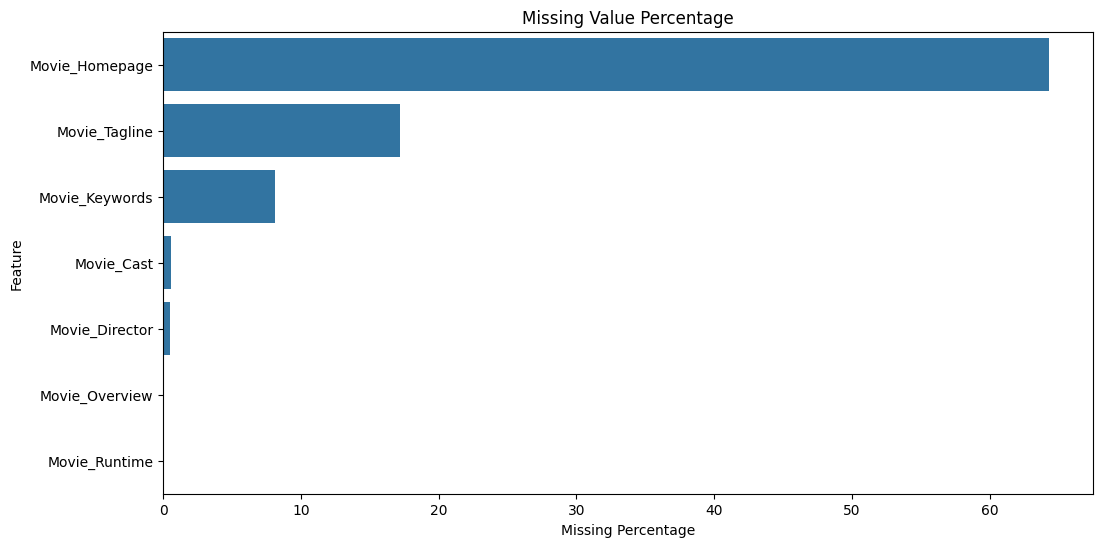

In [75]:
plt.figure(figsize=(12,6))

missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage = missing_percentage[
    missing_percentage > 0
]

sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index
)

plt.title("Missing Value Percentage")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.show()

## 7. Remove Duplicate records

In [76]:
# ==============================
# 7. DUPLICATE REMOVAL
# ==============================

print("Duplicate rows before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows before: 0
Duplicate rows after: 0


## 8. Convert release Date

In [77]:
# ==============================
# 8. DATE FEATURE ENGINEERING
# ==============================

df["Movie_Release_Date"] = pd.to_datetime(
    df["Movie_Release_Date"], format ="%d-%m-%Y",
    errors="coerce"
)

df["Release_Year"] = df["Movie_Release_Date"].dt.year
df["Release_Month"] = df["Movie_Release_Date"].dt.month

df[[
    "Movie_Release_Date",
    "Release_Year",
    "Release_Month"
]].head()

,Movie_Release_Date,Release_Year,Release_Month
0,1995-12-09,1995,12
1,1977-05-25,1977,5
2,2003-05-30,2003,5
3,1994-07-06,1994,7
4,1999-09-15,1999,9


## Explore the Target Variable
A histogram of Movie_Budget helps understand the range of movie production budgets.

The dataset contains movies with relatively small budgets as well as movies with very large production budgets.

count    4.760000e+03
mean     8.263743e+07
std      1.630554e+08
min      0.000000e+00
25%      0.000000e+00
50%      1.944716e+07
75%      9.341276e+07
max      2.787965e+09
Name: Movie_Revenue, dtype: float64


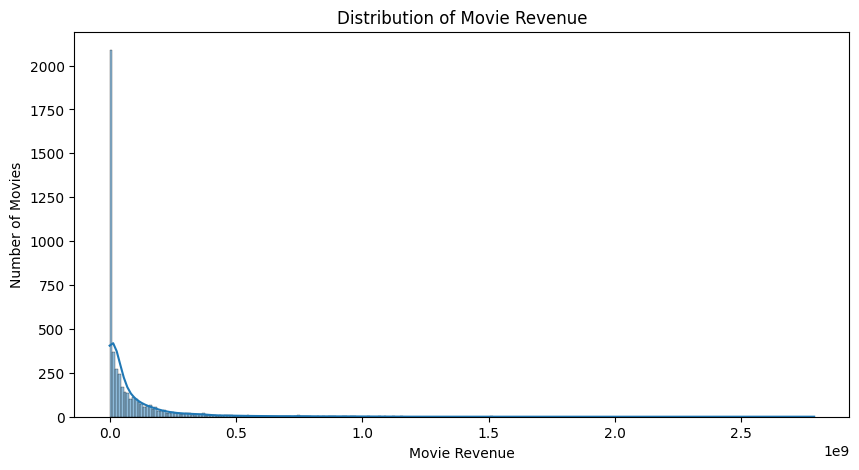

In [78]:
# ==============================
# 9. TARGET VARIABLE ANALYSIS
# ==============================

print(df["Movie_Revenue"].describe())

plt.figure(figsize=(10,5))

sns.histplot(
    df["Movie_Revenue"],
    kde=True
)

plt.title("Distribution of Movie Revenue")
plt.xlabel("Movie Revenue")
plt.ylabel("Number of Movies")

plt.show()

Revenue is usually highly skewed, so we can create a log-transformed target.

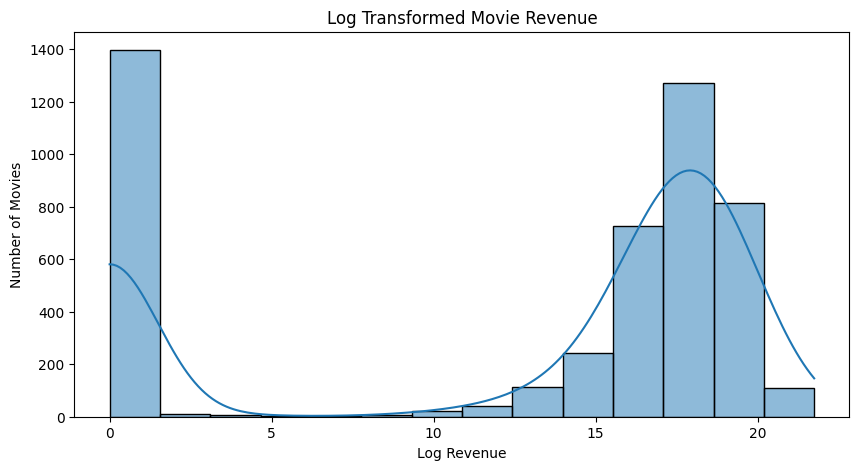

In [79]:
df["Log_Revenue"] = np.log1p(df["Movie_Revenue"])

plt.figure(figsize=(10,5))

sns.histplot(
    df["Log_Revenue"],
    kde=True
)

plt.title("Log Transformed Movie Revenue")
plt.xlabel("Log Revenue")
plt.ylabel("Number of Movies")

plt.show()

A histogram is used to examine the distribution of movie revenue.

Movie revenue is strongly right-skewed because a small number of movies generate extremely high revenue compared with most movies.

Therefore, a log transformation is considered.

## 10. Correlation Analysis
A correlation matrix is created for numerical variables.

It helps identify:

Strong relationships
Weak relationships
Potentially redundant variables
Features related to the target

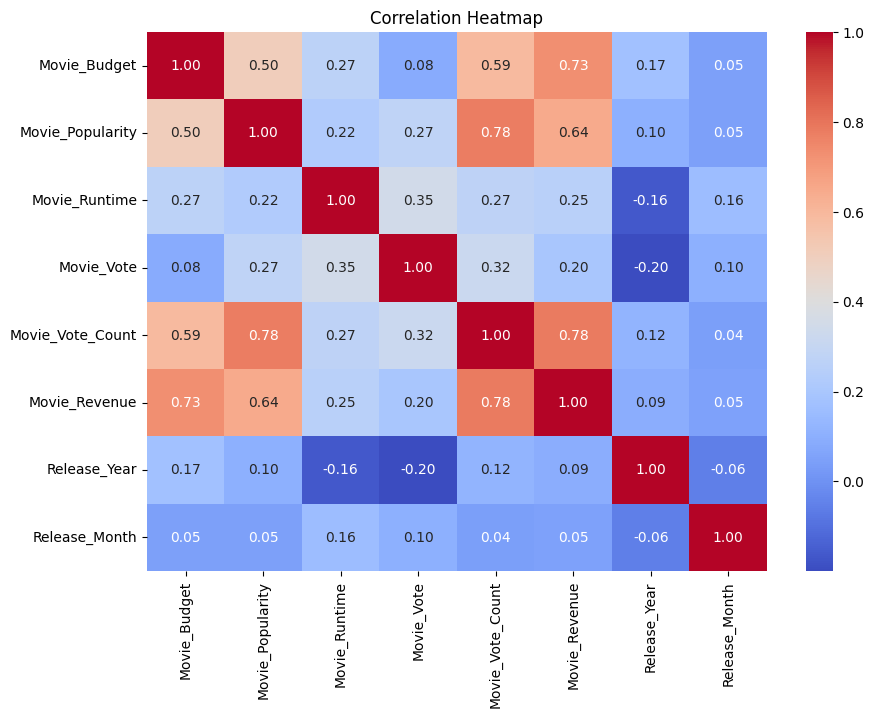

In [80]:
# ==============================
# 10. CORRELATION ANALYSIS
# ==============================

numeric_columns = [
    "Movie_Budget",
    "Movie_Popularity",
    "Movie_Runtime",
    "Movie_Vote",
    "Movie_Vote_Count",
    "Movie_Revenue",
    "Release_Year",
    "Release_Month"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## 11. EDA Visualizations
Exploratory Data Analysis is performed to understand the relationships and patterns within the data.

**Budget vs Revenue:**
A scatter plot is used to analyze whether higher-budget movies tend to generate higher revenue.

This is an important relationship because production budget can be a major factor associated with revenue.

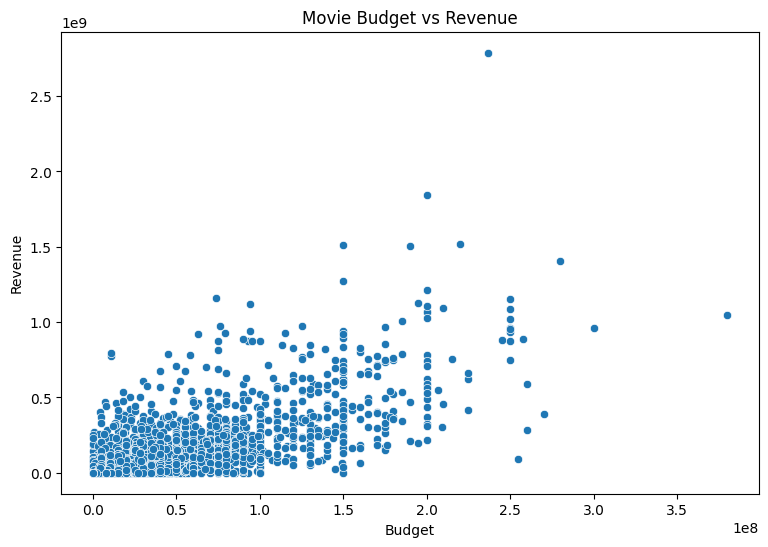

In [81]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Movie_Budget",
    y="Movie_Revenue"
)

plt.title("Movie Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")

plt.show()

**Popularity vs Revenue:**
A scatter plot between Movie_Popularity and Movie_Revenue helps determine whether popularity is associated with financial performance.

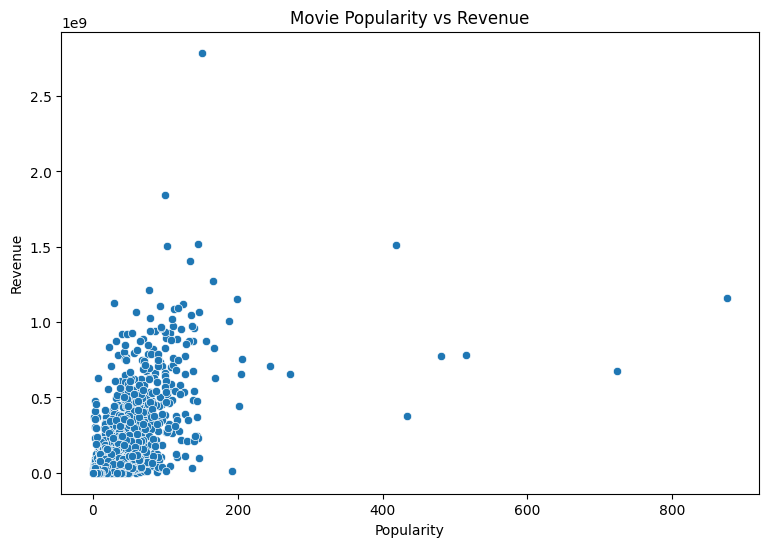

In [82]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Movie_Popularity",
    y="Movie_Revenue"
)

plt.title("Movie Popularity vs Revenue")
plt.xlabel("Popularity")
plt.ylabel("Revenue")

plt.show()

**Vote count vs Revenue :** Movie_Vote_Count is compared with revenue.

This helps examine whether movies with greater audience engagement tend to generate higher revenue.

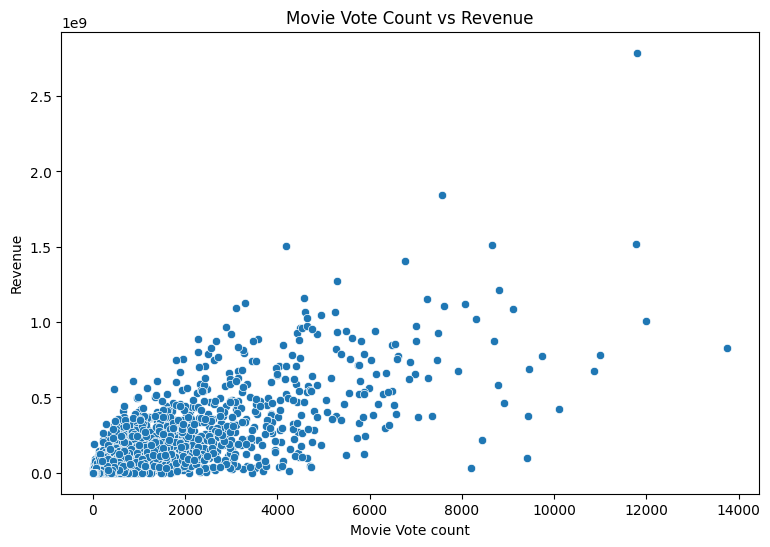

In [83]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Movie_Vote_Count",
    y="Movie_Revenue"
)

plt.title("Movie Vote Count vs Revenue")
plt.xlabel("Movie Vote count")
plt.ylabel("Revenue")

plt.show()

**Revenue by Release Date:**
Average revenue is grouped by release year.

This helps identify changes in revenue patterns over time.

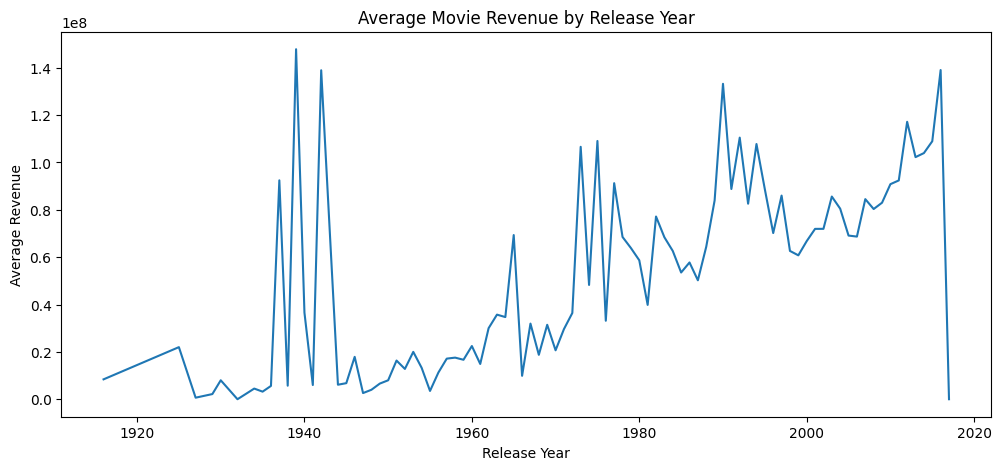

In [84]:
year_revenue = (
    df.groupby("Release_Year")["Movie_Revenue"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=year_revenue,
    x="Release_Year",
    y="Movie_Revenue"
)

plt.title("Average Movie Revenue by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Revenue")

plt.show()

Budget Distribution

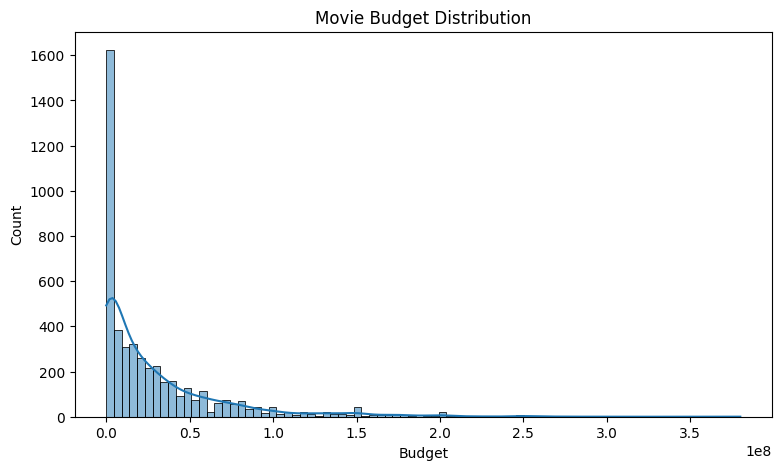

In [85]:
plt.figure(figsize=(9,5))

sns.histplot(
    df["Movie_Budget"],
    kde=True
)

plt.title("Movie Budget Distribution")
plt.xlabel("Budget")

plt.show()

## 12. Select features
For the basic supervised model, we'll use numerical and a few categorical features.

In [86]:
# ==============================
# 12. FEATURE SELECTION
# ==============================

features = [
    "Movie_Budget",
    "Movie_Popularity",
    "Movie_Runtime",
    "Movie_Vote",
    "Movie_Vote_Count",
    "Release_Year",
    "Release_Month",
    "Movie_Genre",
    "Movie_Language",
    "Movie_Production_Country"
]

target = "Log_Revenue"

X = df[features]
y = df[target]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (4760, 10)
y Shape: (4760,)


In [87]:
# We deliberately don't use:

# Movie_Revenue

# as an input feature because it is the original target.

## 13. Identify Numerical and Categorical Columns

Final Features

The final model uses:

* Movie_Budget
* Movie_Popularity
* Movie_Runtime
* Movie_Vote
* Movie_Vote_Count
* Release_Year
* Release_Month
* Movie_Genre
* Movie_Language
* Movie_Production_Country

Numerical features
* Movie_Budget
* Movie_Popularity
* Movie_Runtime
* Movie_Vote
* Movie_Vote_Count
* Release_Year
* Release_Month

Categorical features
* Movie_Genre
* Movie_Language
* Movie_Production_Country

In [88]:
# ==============================
# 13. NUMERICAL / CATEGORICAL
# ==============================

numeric_features = [
    "Movie_Budget",
    "Movie_Popularity",
    "Movie_Runtime",
    "Movie_Vote",
    "Movie_Vote_Count",
    "Release_Year",
    "Release_Month"
]

categorical_features = [
    "Movie_Genre",
    "Movie_Language",
    "Movie_Production_Country"
]

## 14. Train Test Split

The dataset is divided into:

80% training data
20% testing data

using:

train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
Training Dataset

Used to train the machine learning models.

Testing Dataset

Used to evaluate how well the trained models perform on unseen data.

The random_state=42 ensures reproducibility.

In [89]:
# ==============================
# 14. TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3808, 10)
Testing data: (952, 10)


## 15. Preprocessing

This handles:

* Missing values
* Categorical encoding
* Feature scaling



15. Data Preprocessing Steps;

The preprocessing stage contains four major steps.

15.1 Numerical Missing Value Handling

Median imputation is applied:

SimpleImputer(strategy="median")

Median is relatively robust to extreme values.


15.2 Categorical Missing Value Handling

Most-frequent-value imputation is applied:

SimpleImputer(
    strategy="most_frequent"
)

15.3 Categorical Encoding

Machine learning algorithms cannot directly process normal text categories.

Therefore, categorical features are converted using:

One-Hot Encoding

OneHotEncoder(
    handle_unknown="ignore"
)

This creates binary columns for categories such as movie genres and languages.

15.4 Feature Scaling

Numerical features are standardized using:

StandardScaler()

This transforms numerical variables to a comparable scale.

Scaling is particularly important for models such as Linear Regression and Ridge Regression.


In [90]:
# ==============================
# 15. PREPROCESSING
# ==============================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

## 16. Machine Learning Model - Supervised
## Linear Regression

Three basic supervised regression models are used.

Model 1 – Linear Regression

Linear Regression is used as the baseline model.

It attempts to learn a linear relationship between the input features and movie revenue.

Advantages
* Simple
* Easy to interpret
* Fast to train
* Good baseline model
* Limitation

Movie revenue relationships can be complex and may not be completely linear.

In [91]:
# ==============================
# 16. LINEAR REGRESSION
# ==============================

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("Linear Regression completed.")

Linear Regression completed.


## 17. Ridge Regression
Ridge Regression is an extension of Linear Regression that uses regularization.

It helps control model complexity and can reduce the impact of correlated features.

Purpose

Ridge Regression is included to determine whether regularization improves generalization compared with ordinary Linear Regression.

In [92]:
# ==============================
# 17. RIDGE REGRESSION
# ==============================

ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=10))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

print("Ridge Regression completed.")

Ridge Regression completed.


## 18. Random Forest Regression
Random Forest Regression is an ensemble learning method based on multiple decision trees.

It can capture nonlinear relationships between movie characteristics and revenue.

Advantages
Handles nonlinear relationships.
Can model feature interactions.
Generally less dependent on linear assumptions.
Works well with mixed feature relationships.
Limitation
More computationally expensive than Linear Regression.
Can overfit if the model is excessively complex.
Less directly interpretable than Linear Regression.

In [93]:
# ==============================
# 18. RANDOM FOREST REGRESSION
# ==============================

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=15,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Regression completed.")

Random Forest Regression completed.


## 19. Model Evaluation

We'll use:

* MAE
* RMSE
* R² Score

The models are evaluated using three major regression metrics.


19.1 Mean Absolute Error – MAE

MAE measures the average absolute difference between actual and predicted values.

Formula:

MAE = average(|Actual − Predicted|)

Lower MAE indicates better performance.


19.2 Root Mean Squared Error – RMSE

RMSE gives greater importance to larger prediction errors.

Formula:

RMSE = √average((Actual − Predicted)²)

Lower RMSE indicates better performance.

Because movie revenue contains extreme values, RMSE is particularly useful for understanding large prediction errors.


19.3 R² Score

R² indicates how much variation in the target variable is explained by the model.

A higher R² generally indicates better explanatory performance.

In [94]:
# ==============================
# 19. MODEL EVALUATION
# ==============================

def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }


results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        "Ridge Regression",
        y_test,
        ridge_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,5.796409,7.077269,0.240638
1,Ridge Regression,5.666093,6.571991,0.345196
2,Random Forest,2.756171,4.709430,0.663756


## 20. Model Comparison - Visualy

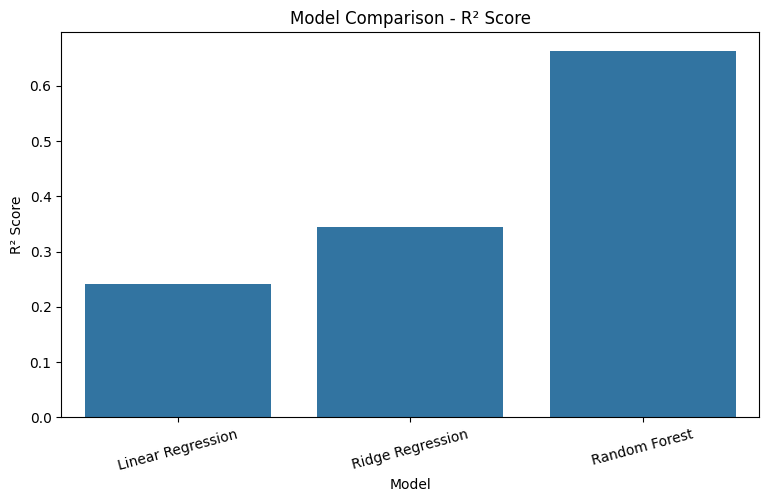

In [95]:
# ==============================
# 20. MODEL COMPARISON
# ==============================

plt.figure(figsize=(9,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.show()

For regression:

* Higher R² → better explanatory performance
* Lower MAE → better
* Lower RMSE → better


## 21. Actual Revenue Prediction
Because we trained on Log_Revenue, convert predictions back to normal revenue.

In [96]:
# ==============================
# 21. CONVERT PREDICTION BACK
# ==============================

actual_revenue = np.expm1(y_test)

rf_revenue_prediction = np.expm1(rf_pred)

prediction_df = pd.DataFrame({
    "Actual Revenue": actual_revenue,
    "Predicted Revenue": rf_revenue_prediction
})

prediction_df.head(10)

,Actual Revenue,Predicted Revenue
2314,0.000000e+00,7.050576e-01
315,1.953128e+08,4.565995e+07
2329,7.350991e+08,6.267508e+08
472,1.530489e+07,6.531561e+07
534,9.996575e+07,8.624878e+07
2451,3.815099e+08,3.225265e+08
4128,0.000000e+00,3.791600e+01
4326,4.037782e+06,1.538845e+00
1469,5.687041e+07,1.645143e+07
2771,0.000000e+00,4.389566e+05


## 22. Actual vs Predicted Plot

## ## Overfitting and Underfitting Analysis

Underfitting

Underfitting occurs when a model is too simple to capture the relationships in the data.

Linear Regression may show signs of underfitting if the actual relationships between movie characteristics and revenue are strongly nonlinear.

Overfitting

Overfitting occurs when a model learns the training data too closely but performs poorly on unseen testing data.

Random Forest can potentially overfit when:

Too many trees are used without appropriate control.
Trees become excessively deep.
The model learns noise from the training data.

Therefore, parameters such as:

max_depth=15

can be used to control tree complexity.

## Bias-Variance Consideration
Linear Regression

Generally has:

* Higher bias
* Lower variance

It is relatively simple and may not capture complex nonlinear relationships.

Random Forest

Generally has:

* Lower bias
* Higher potential variance depending on model complexity

However, using multiple trees can reduce variance compared with a single decision tree.

Ridge Regression

Ridge introduces regularization, which can help control model complexity and reduce variance.

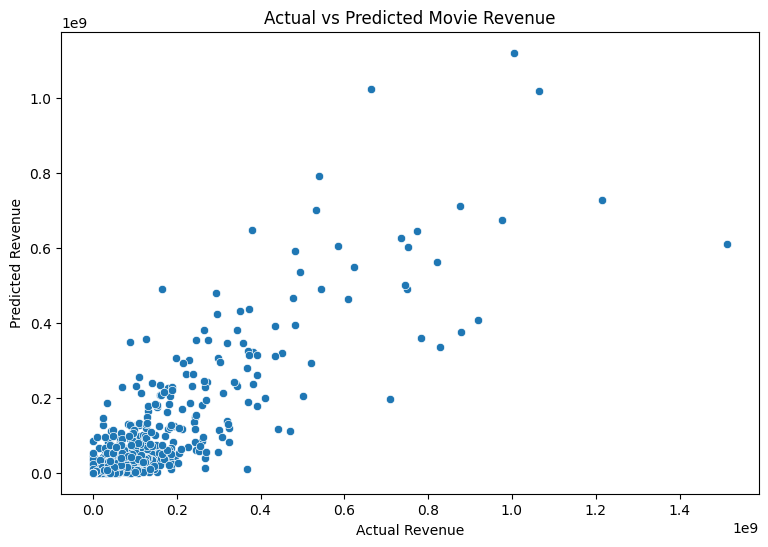

In [97]:
# ==============================
# 22. ACTUAL VS PREDICTED
# ==============================

plt.figure(figsize=(9,6))

sns.scatterplot(
    x=actual_revenue,
    y=rf_revenue_prediction
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.title(
    "Actual vs Predicted Movie Revenue"
)

plt.show()

## 23. Test a new movie

You can enter movie information and predict revenue.

After training, the selected model can accept information about a new movie.

For example:

* Budget              = $50,000,000
* Popularity          = 30
* Runtime             = 120 minutes
* Vote                = 7.0
* Vote Count          = 1,000
* Release Year        = 1995
* Release Month       = 7
* Genre               = Action
* Language            = English
* Production Country  = United States

The model produces a predicted revenue value.

Since the model is trained using logarithmic revenue, the prediction is converted back: exmp1


In [98]:
# ==============================
# 23. NEW MOVIE PREDICTION
# ==============================

new_movie = pd.DataFrame({
    "Movie_Budget": [50000000],
    "Movie_Popularity": [30],
    "Movie_Runtime": [120],
    "Movie_Vote": [7.0],
    "Movie_Vote_Count": [1000],
    "Release_Year": [1995],
    "Release_Month": [7],
    "Movie_Genre": ["Action"],
    "Movie_Language": ["English"],
    "Movie_Production_Country": ["United States of America"]
})

predicted_log_revenue = rf_model.predict(new_movie)

predicted_revenue = np.expm1(
    predicted_log_revenue
)

print(
    "Predicted Movie Revenue: $",
    round(predicted_revenue[0], 2)
)

Predicted Movie Revenue: $ 196254124.43


## 24. Save the Trained Model

After selecting the final model, it is saved using Joblib:

The saved model contains the preprocessing and prediction pipeline.

This allows the same trained model to be loaded later without retraining it.

In [99]:
# ==============================
# 24. SAVE MODEL
# ==============================

joblib.dump(
    rf_model,
    "movie_revenue_model.joblib"
)

print("Model saved successfully!")

Model saved successfully!


Load it later

In [100]:
loaded_model = joblib.load(
    "movie_revenue_model.joblib"
)

prediction = loaded_model.predict(
    new_movie
)

print(
    "Predicted Revenue: $",
    round(np.expm1(prediction[0]), 2)
)

Predicted Revenue: $ 196254124.43


## Final Project Structure

In [101]:
""" MOVIE REVENUE PREDICTION
│
├── 1. Problem Definition
├── 2. Dataset Understanding
├── 3. Data Cleaning
├── 4. Exploratory Data Analysis
├── 5. Data Preprocessing
├── 6. Feature Engineering
├── 7. Feature Selection
├── 8. Train-Test Split
├── 9. Linear Regression
├── 10. Ridge Regression
├── 11. Random Forest Regression
├── 12. Model Evaluation
├── 13. Model Comparison
├── 14. Prediction
├── 15. Conclusion
└── 16. Deployment"""
       

' MOVIE REVENUE PREDICTION\n│\n├── 1. Problem Definition\n├── 2. Dataset Understanding\n├── 3. Data Cleaning\n├── 4. Exploratory Data Analysis\n├── 5. Data Preprocessing\n├── 6. Feature Engineering\n├── 7. Feature Selection\n├── 8. Train-Test Split\n├── 9. Linear Regression\n├── 10. Ridge Regression\n├── 11. Random Forest Regression\n├── 12. Model Evaluation\n├── 13. Model Comparison\n├── 14. Prediction\n├── 15. Conclusion\n└── 16. Deployment'

## Limitations

The prediction system has several limitations.

1. Historical Data

The model learns patterns from historical movies and may not represent future market conditions.

2. Missing Business Factors

Important factors such as marketing expenditure, distribution strategy, actor popularity, competition from other releases, streaming deals, and audience demographics are not necessarily available in the dataset.

3. Revenue Uncertainty

Movie revenue can be affected by unexpected events and market conditions that cannot easily be represented using the available features.

4. Dataset Coverage

The dataset represents a particular collection of movies and historical period, so its predictions should not automatically be considered universally applicable.

5. Prediction Is an Estimate

The model provides an estimated revenue rather than a guaranteed financial outcome.



## Future Enhancements

The project can be improved by adding:

1. Actor/cast popularity
2. Director success rate
3. Production-company history
4. Marketing budget
5. Number of screens/release locations
6. Competition during release period
7. Audience demographic information
8. Streaming-platform data
9. More recent movies
10. Hyperparameter tuning
11. Cross-validation
12. Gradient Boosting
13. XGBoost or similar advanced regression algorithms
14. Feature importance analysis
15. SHAP-based explainability
16. Real-time prediction API
17. Web-based user interface





## Conclusion

This project develops a Movie Revenue Prediction system using supervised machine learning regression.

The Movies Recommendation.csv dataset is transformed from a movie information dataset into a regression problem by selecting Movie_Revenue as the target variable.

The workflow begins with dataset understanding and exploratory data analysis. Missing values and duplicate records are handled, date information is converted into useful numerical features, categorical variables are encoded, numerical variables are scaled, and the highly skewed revenue target is log-transformed.

Three regression algorithms—Linear Regression, Ridge Regression, and Random Forest Regression—are trained and evaluated using MAE, RMSE, and R² Score.

The models are compared using their performance on unseen test data. The final model should be selected based on the actual evaluation results produced by the notebook rather than assuming a particular algorithm will always perform best.

Finally, the selected model is saved and integrated into a Flask REST API, allowing users to provide movie information and receive a predicted revenue value in JSON format. Docker can be used to package and deploy the complete application.

Overall, the project demonstrates a complete machine learning pipeline from problem definition and data analysis to model development, evaluation, and deployment.